In [5]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pynbody
import pynbody.plot.sph as sph
from IPython.display import clear_output, display
import h5py
import cupy
from cupyx.scipy.signal import stft as cupystft

# fourier
from scipy.signal import stft as short_time_fft
from scipy.ndimage import gaussian_filter1d
from scipy.signal import ShortTimeFFT, find_peaks, get_window
from scipy.signal import windows

# dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

SMALLSIZE = 12
NORMALSIZE = 12
LARGESIZE = 12

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

isob_dir = "../data/IsoB_dt10_all"
snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]
iord_dir  = "../data/fil_iords.csv"

HDF5DIR = "../data/IsoB_faceon.h5"
h5keys = [f"GLX{10*(x+1):04.0f}" for x in range(100)]


In [3]:
all_iords = np.loadtxt("../data/all_iords.csv")

In [4]:
with h5py.File('../data/all_stars_dc.h5', 'r') as f:
    data_c = f['coords_data'][:]

print(data_c.shape)

(3, 100, 4590904)


In [5]:
data_ct = np.transpose(data_c, (2,1,0))

with h5py.File("../data/isob10_stars.h5", 'w') as f:
    dset = f.create_dataset(
        "trajectories",
        data=data_ct,
        chunks=(1000,100,3),
        compression="gzip",
        compression_opts=4
    )

    f.create_dataset("iord_map", data=all_iords)


In [38]:
with h5py.File('../data/isob10_stars.h5', 'r') as f:
    dset = f['trajectories']
    print(dset.shape[0])
    i1,i2 = (4000000, 4001000)
    data = dset[i1:i2, :, :]
    iords = f['iord_map'][i1:i2]

4590904


In [34]:
print(data[0, :, 0].shape)

(100,)


In [39]:
with h5py.File("../data/isob10_stars.h5", "r") as f_in, h5py.File("../data/isob10_rfft_psd.h5", "w") as f_out:
    data = f_in['trajectories']

    n_stars = int(data.shape[0])

    psd_h5 = f_out.create_dataset(
        "psd",
        shape=(n_stars, 51, 3), # no. of stars, no. of frequencies (100/2 + 1), no. of spatial dimensions
        dtype=np.float32,
        chunks=(10000, 51, 3),
        compression="gzip",
        compression_opts=4
    )
    
    f_out.create_dataset("iord_map", data=f_in["iord_map"][:])

    dt = 10
    freqs = np.fft.rfftfreq(100, d=dt).astype(np.float32)
    f_out.create_dataset("freqs", data=freqs)

    scaler = cupy.full(51, 2.0, dtype=cupy.float32)
    scaler[0] = 1.0
    scaler[-1] = 1.0
    normalisation = 1 / (100 * 10)

    chunk_stars = 100000
    n_chunks = (n_stars + chunk_stars - 1) // chunk_stars

    print("setup complete")


    for i, chunk_start in enumerate(range(0, n_stars, chunk_stars)):
        chunk_end = min(chunk_start + chunk_stars, n_stars)
        print(f"chunk {i+1}/{n_chunks}")

        chunk_gpu = cupy.asarray(data[chunk_start:chunk_end], dtype=cupy.float32)
        chunk_rfft = cupy.fft.rfft(chunk_gpu, axis=1)
        chunk_psd = (cupy.abs(chunk_rfft) ** 2) * scaler[cupy.newaxis, :, cupy.newaxis] * normalisation

        psd_h5[chunk_start:chunk_end] = cupy.asnumpy(chunk_psd)
        pass

setup complete
chunk 1/46
chunk 2/46
chunk 3/46
chunk 4/46
chunk 5/46
chunk 6/46
chunk 7/46
chunk 8/46
chunk 9/46
chunk 10/46
chunk 11/46
chunk 12/46
chunk 13/46
chunk 14/46
chunk 15/46
chunk 16/46
chunk 17/46
chunk 18/46
chunk 19/46
chunk 20/46
chunk 21/46
chunk 22/46
chunk 23/46
chunk 24/46
chunk 25/46
chunk 26/46
chunk 27/46
chunk 28/46
chunk 29/46
chunk 30/46
chunk 31/46
chunk 32/46
chunk 33/46
chunk 34/46
chunk 35/46
chunk 36/46
chunk 37/46
chunk 38/46
chunk 39/46
chunk 40/46
chunk 41/46
chunk 42/46
chunk 43/46
chunk 44/46
chunk 45/46
chunk 46/46


In [54]:
with h5py.File('../data/isob10_rfft_psd.h5', 'r') as f:
    dset = f['psd'][0:1000]
    #print(dset[0,:,:])
    freqs = f['freqs'][:]
    print(freqs)

    print(dset)

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05 ]
[[[1.2974279e-03 3.4848326e-03 8.2032078e-05]
  [3.2891077e-03 6.9678975e-03 2.9128816e-04]
  [2.3959402e-03 5.8774296e-03 1.8943263e-04]
  ...
  [1.3131247e-03 1.0070768e-03 5.6410115e-03]
  [1.4301260e-02 4.7706123e-03 6.3457675e-03]
  [6.5468089e-06 2.5835724e-03 3.9866245e-03]]

 [[2.4459498e-01 1.5050532e+00 5.2877999e-04]
  [2.5018480e-01 1.2851371e+00 5.8686649e-03]
  [2.4950480e+00 4.4781389e+00 3.4715598e-03]
  ...
  [1.8655064e-03 2.1317279e-05 5.0831300e-06]
  [1.3974480e-03 1.2410897e-05 1.3888967e-05]
  [9.2386652e-04 4.3938458e-06 6.3125503e-07]]

 [[6.9918740e-03 2.8958407e-04 8.6140091e-05]
  [1.9945072e-02 8.9701237e-03 8.0772609e-02]
  [1.0418297e-02 2.3980763e-

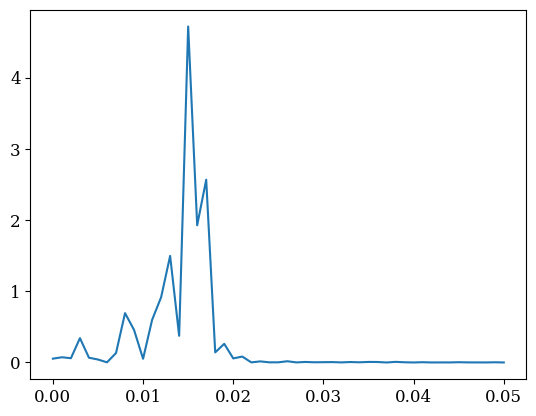

In [68]:
id = 50
test = dset[id, :, 0]

fig, ax = plt.subplots()
ax.plot(freqs, test)

In [ ]:
print(sim.s['tform'].shape)

np.loadtxt("../data/all_iords.csv").shape

(4590904,)


In [36]:
#df_sort = df.set_index('iord').reindex(target_iords)

sim = pynbody.load("../data/IsoB_dt10_all/GLX.01000")
sim.physical_units()
pynbody.analysis.angmom.faceon(sim)

tforms = sim.s['tform'].in_units("Myr")
iords = sim.s['iord']
target_iords = np.loadtxt("../data/all_iords.csv")

print(sim.s.all_keys())

['HII', 'HeIII', 'ne', 'hetot', 'hydrogen', 'feh', 'oxh', 'ofe', 'mgfe', 'nefe', 'sife', 'c_s', 'c_s_turb', 'mjeans', 'mjeans_turb', 'ljeans', 'ljeans_turb', 'U_mag', 'U_lum_den', 'B_mag', 'B_lum_den', 'V_mag', 'V_lum_den', 'R_mag', 'R_lum_den', 'I_mag', 'I_lum_den', 'J_mag', 'J_lum_den', 'H_mag', 'H_lum_den', 'K_mag', 'K_lum_den', 'u_mag', 'u_lum_den', 'g_mag', 'g_lum_den', 'r_mag', 'r_lum_den', 'i_mag', 'i_lum_den', 'z_mag', 'z_lum_den', 'y_mag', 'y_lum_den', 'r', 'rxy', 'vr', 'v2', 'vt', 'ke', 'te', 'j', 'j2', 'jz', 'vrxy', 'vcxy', 'vphi', 'vtheta', 'v_mean', 'v_disp', 'v_curl', 'vorticity', 'v_div', 'age', 'theta', 'alt', 'az', 'cs', 'mu', 'p', 'u', 'temp', 'zeldovich_offset', 'aform', 'tform', 'iord_argsort', 'smooth', 'rho', 'OxMassFrac', 'timeform', 'uHot', 'u', 'metals', 'MassHot', 'mass', 'tform', 'HeII', 'HI', 'massform', 'massHot', 'iord', 'vel', 'HeI', 'phi', 'tempEff', 'FeMassFrac', 'uDotFB', 'igasorder', 'eps', 'Tinc', 'pos']


In [37]:
temp_df = pd.DataFrame(dict(iord = iords, tform = tforms))

print(temp_df)

sorted_df = temp_df.set_index("iord").reindex(target_iords)

               iord         tform
0        1006000000  14989.197997
1        1006000001  14989.197997
2        1006000002  14989.197997
3        1006000003  14989.197997
4        1006000004  14989.197997
...             ...           ...
4666405  1010666405    999.963560
4666406  1010666406    999.963560
4666407  1010666407    999.963560
4666408  1010666408    999.963560
4666409  1010666409    999.963560

[4666410 rows x 2 columns]


                     tform
iord                      
1.006000e+09  14989.197997
1.006000e+09  14989.197997
1.006000e+09  14989.197997
1.006000e+09  14989.197997
1.006000e+09  14989.197997
...                    ...
1.010666e+09    999.963560
1.010666e+09    999.963560
1.010666e+09    999.963560
1.010666e+09    999.963560
1.010666e+09    999.963560

[4590904 rows x 1 columns]


(array([826025., 380614., 367421., 374204., 516464., 305799., 269581.,
        188360., 169911., 153679.]),
 array([9.99963515e-01, 1.00896323e+02, 2.00792683e+02, 3.00689042e+02,
        4.00585402e+02, 5.00481762e+02, 6.00378121e+02, 7.00274481e+02,
        8.00170841e+02, 9.00067200e+02, 9.99963560e+02]),
 <BarContainer object of 10 artists>)

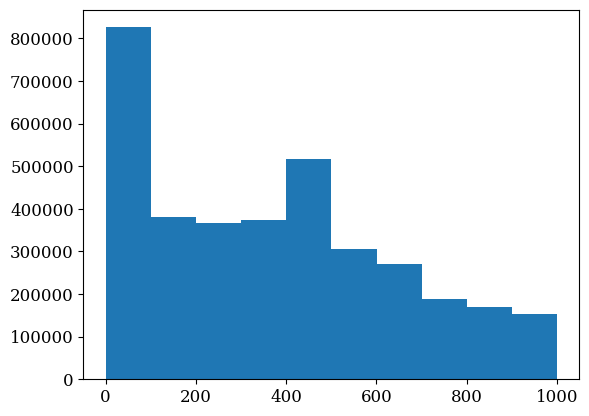

In [45]:
print(sorted_df)

fig, ax = plt.subplots()

ax.hist(sorted_df[sorted_df['tform'] < 1000]['tform'])

In [66]:
np.savetxt("../data/fil_tforms.csv", sorted_df['tform'].to_numpy(), delimiter=",")

# STFT

In [6]:
## constants
dt = 10
TIMESTEPS = 100
CHUNK_MAX = 100000

## constants related to stft
WIN = 20
HOP = 10
N_FREQS = WIN // 2 + 1
N_WIN = 1 + (TIMESTEPS - WIN) // HOP
normalisation = 1.0 / (WIN * dt)


# loading tforms and making them steps for easing batching similar populations to the gpu
tforms = np.loadtxt("../data/fil_tforms.csv")


tform_step = np.floor(tforms/dt).astype(int)
tform_step[tforms > 5000] = 0

n_timesteps = TIMESTEPS - tform_step  # array with the number of timesteps which should be analysed

def hanning(win_size):
    n = cupy.arange(win_size, dtype=cupy.float32)
    return 0.5 - 0.5 * cupy.cos(2.0 * cupy.pi * n / (win_size - 1))

def gpu_stft(gpu_chunk, n_valid, hann):
    chunk_size = gpu_chunk.shape[0]
    n_frames = 1 + (n_valid - WIN) // HOP

    frame_starts = cupy.arange(n_frames) * HOP
    indices = frame_starts[:, None] + cupy.arange(WIN)[None, :]

    frames = gpu_chunk[:, indices, :]

    frames = frames*hann[None, None, :, None]

    fft = cupy.fft.rfft(frames, axis=2)

    scaler = cupy.full(N_FREQS, 2.0, dtype=cupy.float32)
    scaler[0] = 1
    scaler[-1] = 1
    psd = (cupy.abs(fft) ** 2) * scaler[None, None, :, None] * normalisation
    
    return psd, n_frames


def gpu_stft2(gpu_chunk, win, hop, dt):

    f, t, zxx = cupystft(
        gpu_chunk,
        fs = 1/dt,
        window='hann',
        nperseg=win,
        noverlap=win-hop,
        nfft=win,
        boundary=None,
        padded=False,
        axis=-1,
        scaling='psd'
    )
    psd = (cupy.abs(zxx)).transpose(0, 3, 2, 1)
    return psd



In [ ]:
## OLD STFT IMPLEMENTATION

with h5py.File("../data/isob10_stars.h5") as f_in, h5py.File("../data/isob10_stft_psd.h5", "w") as f_out:
    data = f_in['trajectories']

    N_STARS = data.shape[0]

    stft_results = f_out.create_dataset(
        "psd",
        shape=(N_STARS, N_WIN, N_FREQS, 3), # number of stars, number of windows, number of frequencies, and number of spatial dimensions
        dtype=np.float32,
        chunks = (10000, N_WIN, N_FREQS, 3),
        compression = "gzip",
        compression_opts = 4,
        fillvalue=np.nan
    )


    f_out.create_dataset("iord_map", data=f_in["iord_map"][:])
    f_out.create_dataset("tform_steps", data=tform_step)
    f_out.create_dataset("freqs", data=np.fft.rfftfreq(WIN, d=dt).astype(np.float32))

    frame_times = np.array([(i * HOP + WIN / 2) * dt for i in range(N_WIN)], dtype=np.float32)
    f_out.create_dataset("frame_times_Myr", data=frame_times)

    f_out.attrs.update({
        "WIN": WIN,
        "HOP": HOP,
        "window_Myr": WIN * dt,
        "hop_Myr": HOP * dt,
        "max_frames": N_WIN,
        "n_freq": N_FREQS,
        "dt_Myr": dt
    })

    hann = hanning(WIN)

    tform_chunks = np.unique(tform_step)
    n_chunks = len(tform_chunks)

    n_failed = 0 # counter for number of stars which are not long enough
    n_processed = 0 # successfully finished

    for i, t_step in enumerate(tform_chunks):
        star_index = np.where(tform_step == t_step)[0]
        n_valid = TIMESTEPS - t_step

        if n_valid < WIN:
            n_failed += len(star_index)
            continue

        #n_frames = 1 + (n_valid - WIN) // HOP

        for chunk_start in range(0, len(star_index), CHUNK_MAX):
            chunk_end = min(chunk_start + CHUNK_MAX, len(star_index))
            idx = star_index[chunk_start:chunk_end]

            if np.all(np.diff(idx) == 1):
                spatial_data = data[idx[0]:idx[-1]+1, t_step:, :]
            else:
                spatial_data = data[idx, t_step:, :]


            gpu_chunk = cupy.asarray(spatial_data, dtype=cupy.float32)
            psd, n_frames_out = gpu_stft(gpu_chunk, n_valid, hann)

            out = np.full((len(idx), N_WIN, N_FREQS, 3), np.nan, dtype=np.float32)
            out[:, :n_frames_out, :, :] = cupy.asnumpy(psd)

            stft_results[idx[0]:idx[-1]+1] = out
            n_processed += len(idx)

        print(t_step)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [7]:
# NEW

with h5py.File("../data/isob10_stars.h5") as f_in, h5py.File("../data/fft_results/isob10_stft_psd2.h5", "w") as f_out:
    data = f_in['trajectories']

    N_STARS = data.shape[0]

    stft_results = f_out.create_dataset(
        "psd",
        shape=(N_STARS, N_WIN, N_FREQS, 3), # number of stars, number of windows, number of frequencies, and number of spatial dimensions
        dtype=np.float32,
        chunks = (10000, N_WIN, N_FREQS, 3),
        compression = "gzip",
        compression_opts = 4,
        fillvalue=np.nan
    )


    f_out.create_dataset("iord_map", data=f_in["iord_map"][:])
    f_out.create_dataset("tform_steps", data=tform_step)
    f_out.create_dataset("freqs", data=np.fft.rfftfreq(WIN, d=dt).astype(np.float32))

    frame_times = np.array([(i * HOP + WIN / 2) * dt for i in range(N_WIN)], dtype=np.float32)
    f_out.create_dataset("frame_times_Myr", data=frame_times)

    f_out.attrs.update({
        "WIN": WIN,
        "HOP": HOP,
        "window_Myr": WIN * dt,
        "hop_Myr": HOP * dt,
        "max_frames": N_WIN,
        "n_freq": N_FREQS,
        "dt_Myr": dt
    })



    tform_chunks = np.unique(tform_step)
    n_chunks = len(tform_chunks)

    n_failed = 0 # counter for number of stars which are not long enough
    n_processed = 0 # successfully finished

    for i, t_step in enumerate(tform_chunks):
        star_index = np.where(tform_step == t_step)[0]
        n_valid = TIMESTEPS - t_step

        if n_valid < WIN:
            n_failed += len(star_index)
            continue

        n_frames = 1 + (n_valid - WIN) // HOP

        for chunk_start in range(0, len(star_index), CHUNK_MAX):
            chunk_end = min(chunk_start + CHUNK_MAX, len(star_index))
            idx = star_index[chunk_start:chunk_end]

            if np.all(np.diff(idx) == 1):
                spatial_data = data[idx[0]:idx[-1]+1, t_step:, :]
            else:
                spatial_data = data[idx, t_step:, :]


            gpu_chunk = cupy.asarray(spatial_data, dtype=cupy.float32).transpose(0, 2, 1)
            
            psd = gpu_stft2(gpu_chunk, win=WIN, hop=HOP, dt=dt)

            #psd, n_frames_out = gpu_stft(gpu_chunk, n_valid, hann)

            out = np.full((len(idx), N_WIN, N_FREQS, 3), np.nan, dtype=np.float32)
            out[:, :n_frames, :, :] = cupy.asnumpy(psd)

            stft_results[idx[0]:idx[-1]+1] = out
            n_processed += len(idx)

        print(t_step)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [189]:
r1, r2 = (2000000, 2001000)

with h5py.File("../data/isob10_stft_psd.h5", "r") as f:
    print(f['psd'])
    freqs = f['freqs'][:]
    frame_centres = f['frame_times_Myr'][:]
    psd = f['psd'][r1:r2, :, :, :]
    iord1 = f['iord_map'][r1:r2]

with h5py.File("../data/isob10_stars.h5", "r") as f:
    traj = f['trajectories'][r1:r2, :, :]
    iord2 = f['iord_map'][r1:r2]

print(np.all(iord1==iord2))

print(iord1[0])

<HDF5 dataset "psd": shape (4590904, 9, 11, 3), type "<f4">
True
1008063133.0


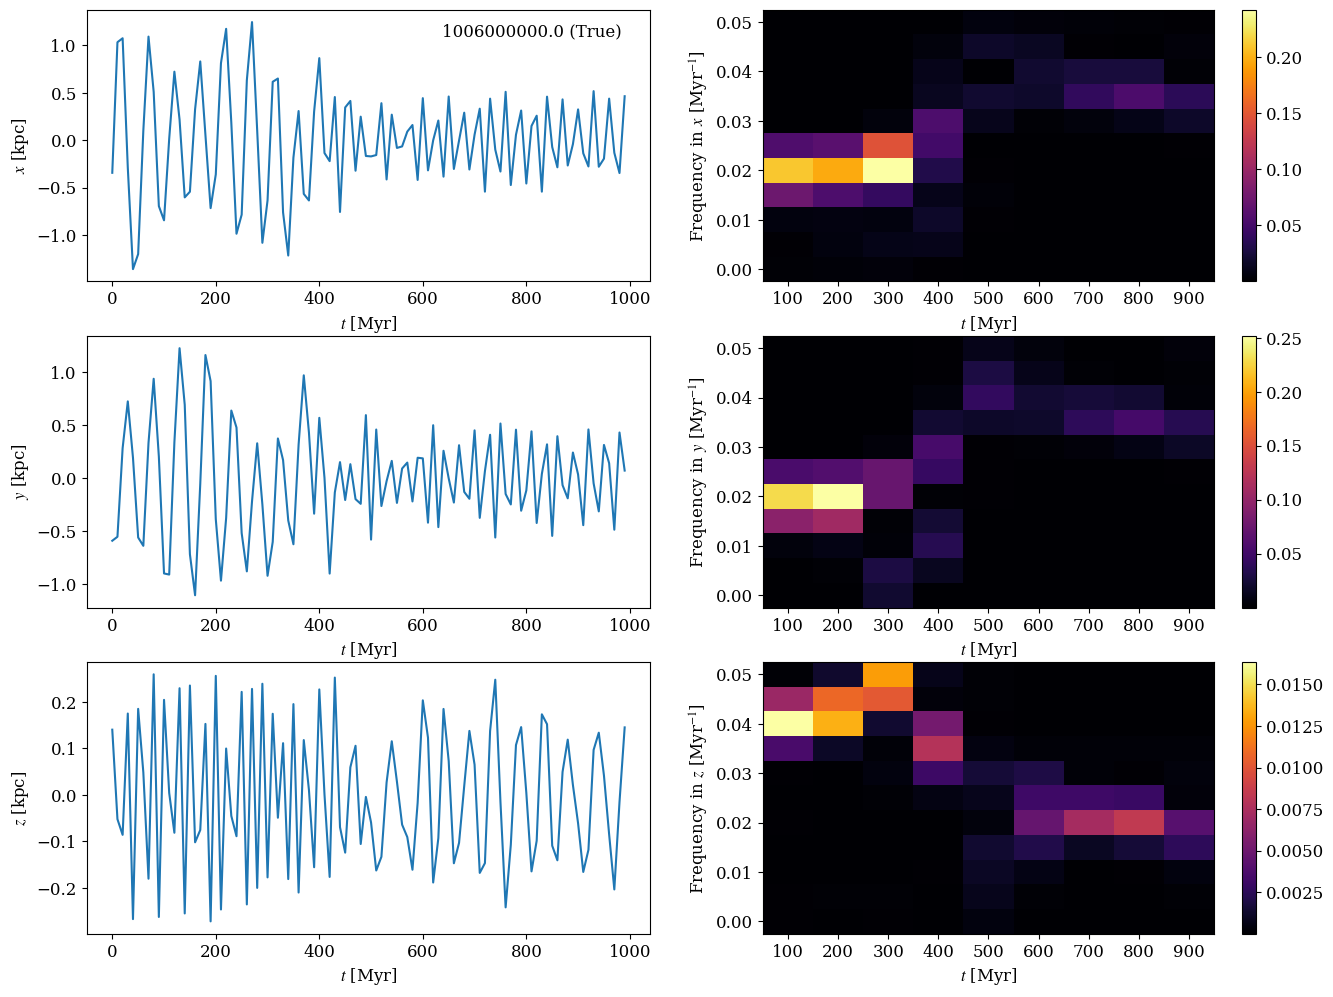

In [161]:
fig, axes = plt.subplots(nrows = 3, ncols = 2)
fig.set_size_inches(8*2, 6*2)
axes = axes.ravel()

id = 0
t = np.arange(100)*10

x = traj[id, :, 0]
y = traj[id, :, 1]
z = traj[id, :, 2]


ax = axes[0]
ax.plot(t, x)
ax.set(xlabel="$t$ [Myr]", ylabel="$x$ [kpc]")
ax.annotate(
    f"{iord1[id]} ({iord1[id] == iord2[id]})",
    xy=(0.95, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="right"
)

ax = axes[1]
im = ax.pcolormesh(frame_centres, freqs, psd[id, :, :, 0].T, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $x$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)


ax = axes[2]
ax.plot(t, y)
ax.set(xlabel="$t$ [Myr]", ylabel="$y$ [kpc]")
ax = axes[3]
im = ax.pcolormesh(frame_centres, freqs, psd[id, :, :, 1].T, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $y$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)


ax = axes[4]
ax.plot(t, z)
ax.set(xlabel="$t$ [Myr]", ylabel="$z$ [kpc]")
ax = axes[5]
im = ax.pcolormesh(frame_centres, freqs, psd[id, :, :, 2].T, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $z$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)

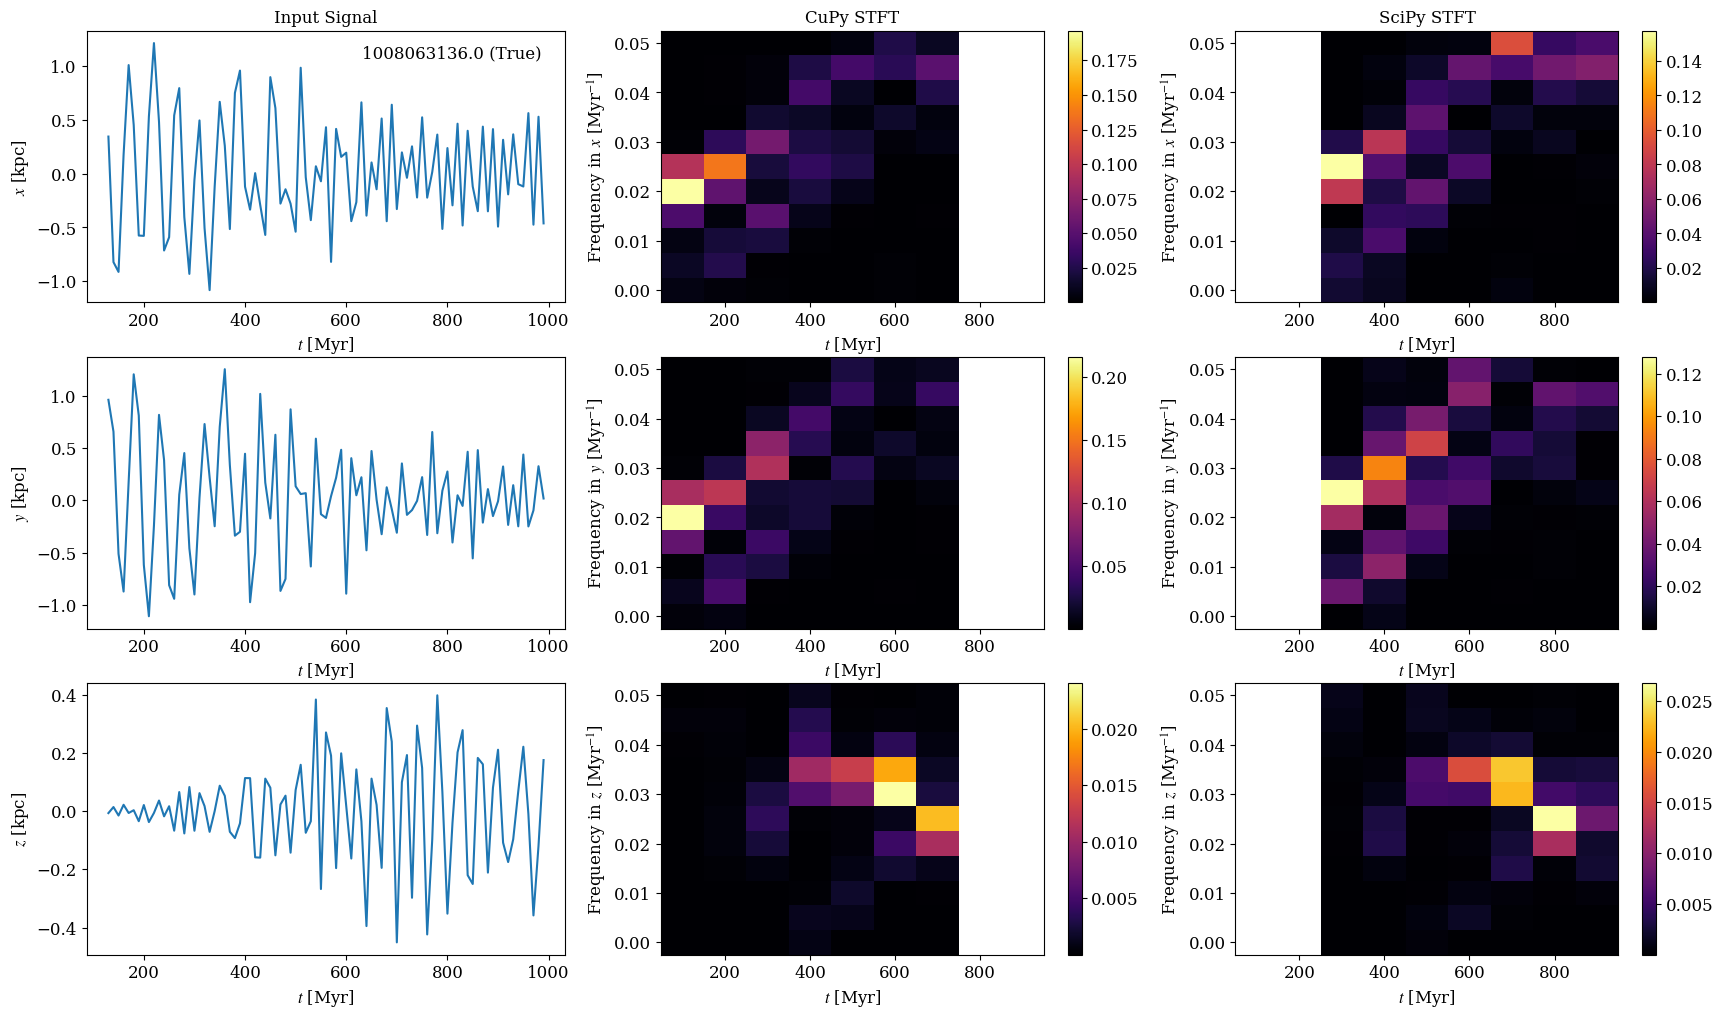

In [190]:
from scipy.signal import stft

# test_signal = x = traj[id, :, 1]

def test_stft(test_signal):
    freqs, times, zxx = stft(
        test_signal,
        fs = 1/10,
        window="hann",
        nperseg=20,
        noverlap=10,
        nfft=20,
        boundary=None,
        padded=False
    )
    psd = (np.abs(zxx) ** 2)

    return freqs, times, psd

# fig, ax = plt.subplots()
# ax.pcolormesh(times, freqs, psd, cmap='inferno')


###############


fig, axes = plt.subplots(nrows = 3, ncols = 3)
fig.set_size_inches(7*3, 6*2)
axes = axes.ravel()

id = 3 
t = np.arange(100)*10

x = traj[id, :, 0]
y = traj[id, :, 1]
z = traj[id, :, 2]

x_f, x_t, x_psd = test_stft(x)
y_f, y_t, y_psd = test_stft(y)
z_f, z_t, z_psd = test_stft(z)

###############
ax = axes[0]
ax.plot(t, x)
ax.set(xlabel="$t$ [Myr]", ylabel="$x$ [kpc]", title="Input Signal")
ax.annotate(
    f"{iord1[id]} ({iord1[id] == iord2[id]})",
    xy=(0.95, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="right"
)

ax = axes[1]
im = ax.pcolormesh(frame_centres, freqs, psd[id, :, :, 0].T, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $x$ [Myr$^{-1}$]", title="CuPy STFT")
cbar = fig.colorbar(im, ax=ax)

ax = axes[2]
im = ax.pcolormesh(x_t, x_f, x_psd, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $x$ [Myr$^{-1}$]", title="SciPy STFT")
cbar = fig.colorbar(im, ax=ax)


###########

ax = axes[3]
ax.plot(t, y)
ax.set(xlabel="$t$ [Myr]", ylabel="$y$ [kpc]")
ax = axes[4]
im = ax.pcolormesh(frame_centres, freqs, psd[id, :, :, 1].T, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $y$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)

ax = axes[5]
im = ax.pcolormesh(y_t, y_f, y_psd, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $y$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)


###########

ax = axes[6]
ax.plot(t, z)
ax.set(xlabel="$t$ [Myr]", ylabel="$z$ [kpc]")
ax = axes[7]
im = ax.pcolormesh(frame_centres, freqs, psd[id, :, :, 2].T, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $z$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)

ax = axes[8]
im = ax.pcolormesh(z_t, z_f, z_psd, cmap='inferno')
ax.set(xlabel="$t$ [Myr]", ylabel="Frequency in $z$ [Myr$^{-1}$]")
cbar = fig.colorbar(im, ax=ax)